In [157]:
import json

import cmasher as cmr
import gc_utils
import h5py
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from astropy.stats import biweight_location
from matplotlib import cm
from matplotlib.animation import PillowWriter
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm, Normalize
from matplotlib.ticker import LogLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d, zoom
from scipy.optimize import curve_fit
from scipy.signal import savgol_filter
from scipy.stats import binned_statistic_2d

In [158]:
sim = "m12i"
# group_id = 1920378
snap_lim = 46

# about 2 minutes to run on 101 iterations
it_min = 0
it_max = 100

tform_bins = 6  # m12b: 8, m12c: 12, m12f: 8, m12i: 6, m12m: 4

In [159]:
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"

pub_data = sim_dir + "snapshot_times_public.txt"
pub_snaps = pd.read_table(pub_data, comment="#", header=None, sep=r"\s+")
pub_snaps.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
snap_lst = pub_snaps["index"].to_numpy()
time_lst = pub_snaps["time_Gyr"].to_numpy()

snap_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["index"].to_numpy()
time_lst = pub_snaps[pub_snaps["index"] >= snap_lim]["time_Gyr"].to_numpy()

# all_data = sim_dir + "/" + sim + "/" + sim + "_res7100/" + "snapshot_times.txt"
# all_snaps = pd.read_table(all_data, comment="#", header=None, sep=r"\s+")
# all_snaps.columns = [
#     "index",
#     "scale_factor",
#     "redshift",
#     "time_Gyr",
#     "lookback_time_Gyr",
#     "time_width_Myr",
# ]

proc_file = sim_dir + sim + "/" + sim + "_processed.hdf5"
proc_data = h5py.File(proc_file, "r")  # open processed data file

grp_file = sim_dir + sim + "/" + "gc_groups.json"
with open(grp_file, "r") as file:
    grp_dict = json.load(file)

grp_lst = [int(grp) for grp in grp_dict[sim].keys()]
grp_lst

[0, 1920378, 4414957, 8580896, 13687078, 16199669, 19898495]

In [160]:
group_dict_lst = []

for group_id in grp_lst[1:]:
    print(group_id)
    it_dict = {gc_utils.iteration_name(it): {} for it in range(it_min, it_max + 1)}

    for it_id in it_dict.keys():
        src_dat = proc_data[it_id]["source"]
        ana_msk = src_dat["analyse_flag"][()] == 1
        grp_msk_src = src_dat["group_id"][()] == group_id

        snp_dat_600 = proc_data[it_id]["snapshots"]["snap600"]
        grp_msk_600 = snp_dat_600["group_id"][()] == group_id
        gc_sur_lst = snp_dat_600["gc_id"][grp_msk_600]

        gc_dict = {gcid: {} for gcid in gc_sur_lst}

        for gcid in gc_dict.keys():
            gcid_idx = np.where(src_dat["gc_id"][ana_msk & grp_msk_src] == gcid)[0][0]
            if group_id == 0:
                tform = src_dat["form_time"][ana_msk & grp_msk_src][gcid_idx]
            else:
                tform = src_dat["t_acc"][ana_msk & grp_msk_src][gcid_idx]
            gc_dict[gcid]["tform"] = tform

        it_dict[it_id] = gc_dict

    tform_all = []
    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            tform_all.append(it_dict[it_id][gcid]["tform"])
    tform_unq = np.unique(np.array(tform_all))

    if group_id == 0:
        tform_bins = tform_bins
    else:
        tform_bins = 1

    vmin, vmax = np.min(tform_unq), np.max(tform_unq)
    bin_edges = np.linspace(vmin, vmax, tform_bins + 1)
    bin_indices = np.digitize(tform_unq, bin_edges, right=False) - 1
    bin_indices[bin_indices == tform_bins] = tform_bins - 1

    # for i in range(tform_bins):
    #     bin_vals = tform_unq[bin_indices == i]
    #     print(f"Bin {i + 1}:")
    #     print(f"  Time range: {bin_edges[i]:.3f} to {bin_edges[i + 1]:.3f}")
    #     print(f"  Count: {len(bin_vals)}")
    #     print(f"  Values: {np.round(bin_vals, 3)}\n")

    tform_to_bin = {t: b for t, b in zip(tform_unq, bin_indices)}

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            tform = it_dict[it_id][gcid]["tform"]
            tform_grp = tform_to_bin[tform]
            it_dict[it_id][gcid]["tform_grp"] = tform_grp

    # Initialize bin counts
    tform_bin_cnts = {i: 0 for i in range(tform_bins)}

    # Count how many GCs are in each tform_grp
    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            grp = it_dict[it_id][gcid]["tform_grp"]
            tform_bin_cnts[grp] += 1

    # Print the counts
    bin_edge_dict = {}
    print("GC counts per tform_grp bin:")

    cmap = plt.get_cmap("tab20")
    colors = [cmap(i) for i in np.linspace(0, 1, len(tform_bin_cnts))]

    for i in range(tform_bins):
        bin_edge_dict[i] = {}
        bin_edge_dict[i]["edge_l"] = bin_edges[i]
        bin_edge_dict[i]["edge_u"] = bin_edges[i + 1]
        print(f"  Bin {i} ({bin_edges[i]:.3f} – {bin_edges[i + 1]:.3f}): {tform_bin_cnts[i]} GCs")

    # for it_id in it_dict.keys():
    #     for gcid in it_dict[it_id].keys():
    #         tform_grp = np.where(tform_unq == it_dict[it_id][gcid]["tform"])[0][0]
    #         it_dict[it_id][gcid]["tform_grp"] = tform_grp

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["et_norm"] = []
            it_dict[it_id][gcid]["jr"] = []
            it_dict[it_id][gcid]["jp"] = []
            it_dict[it_id][gcid]["jz"] = []

    for it_id in it_dict.keys():
        for snap in snap_lst:
            snap_id = gc_utils.snapshot_name(snap)

            snp_dat = proc_data[it_id]["snapshots"][snap_id]
            acc_msk = snp_dat["now_accreted"][()] == 1
            bnd_msk = snp_dat["bound_flag"][()] == 1
            grp_msk = snp_dat["group_id"][()] == group_id

            gc_snp_lst = snp_dat["gc_id"][acc_msk & bnd_msk & grp_msk]

            for gcid in it_dict[it_id].keys():
                if gcid not in gc_snp_lst:
                    it_dict[it_id][gcid]["et_norm"].append(0)
                    it_dict[it_id][gcid]["jr"].append(0)
                    it_dict[it_id][gcid]["jp"].append(0)
                    it_dict[it_id][gcid]["jz"].append(0)

                else:
                    gcid_idx = np.where(snp_dat["gc_id"][acc_msk & bnd_msk & grp_msk] == gcid)[0][0]
                    et_norm = snp_dat["et_norm"][acc_msk & bnd_msk & grp_msk][gcid_idx]
                    j_cyl = snp_dat["j.cyl"][acc_msk & bnd_msk & grp_msk][gcid_idx]

                    it_dict[it_id][gcid]["et_norm"].append(et_norm)
                    it_dict[it_id][gcid]["jr"].append(j_cyl[0])
                    it_dict[it_id][gcid]["jp"].append(j_cyl[1])
                    it_dict[it_id][gcid]["jz"].append(j_cyl[2])

    for it_id in it_dict.keys():
        for gcid in it_dict[it_id].keys():
            it_dict[it_id][gcid]["det_norm"] = np.diff(it_dict[it_id][gcid]["et_norm"])
            it_dict[it_id][gcid]["djr"] = np.diff(it_dict[it_id][gcid]["jr"])
            it_dict[it_id][gcid]["djp"] = np.diff(it_dict[it_id][gcid]["jp"])
            it_dict[it_id][gcid]["djz"] = np.diff(it_dict[it_id][gcid]["jz"])

            all_zeros = not np.any(it_dict[it_id][gcid]["det_norm"])
            if all_zeros:
                it_dict[it_id][gcid]["det_norm_path"] = np.nan
                it_dict[it_id][gcid]["det_norm_net"] = np.nan

                it_dict[it_id][gcid]["djr_path"] = np.nan
                it_dict[it_id][gcid]["djr_net"] = np.nan

                it_dict[it_id][gcid]["djp_path"] = np.nan
                it_dict[it_id][gcid]["djp_net"] = np.nan

                it_dict[it_id][gcid]["djz_path"] = np.nan
                it_dict[it_id][gcid]["djz_net"] = np.nan

                it_dict[it_id][gcid]["first_term"] = 0
                it_dict[it_id][gcid]["last_term"] = 0
                continue

            first_term_idx = np.min(np.nonzero(it_dict[it_id][gcid]["et_norm"]))
            last_term_idx = np.max(np.nonzero(it_dict[it_id][gcid]["et_norm"]))

            it_dict[it_id][gcid]["det_norm"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djr"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djp"][first_term_idx - 1] = 0
            it_dict[it_id][gcid]["djz"][first_term_idx - 1] = 0

            # if GC does not survive to z = 0
            # this just here as an ensurance as by selection they survive to z = 0
            if last_term_idx < len(it_dict[it_id][gcid]["det_norm"]) - 1:
                it_dict[it_id][gcid]["det_norm"][last_term_idx] = 0
                it_dict[it_id][gcid]["djr"][last_term_idx] = 0
                it_dict[it_id][gcid]["djp"][last_term_idx] = 0
                it_dict[it_id][gcid]["djz"][last_term_idx] = 0

            det_norm_net = (
                it_dict[it_id][gcid]["et_norm"][last_term_idx]
                - it_dict[it_id][gcid]["et_norm"][first_term_idx]
            )
            djr_net = it_dict[it_id][gcid]["jr"][last_term_idx] - it_dict[it_id][gcid]["jr"][first_term_idx]
            djp_net = it_dict[it_id][gcid]["jp"][last_term_idx] - it_dict[it_id][gcid]["jp"][first_term_idx]
            djz_net = it_dict[it_id][gcid]["jz"][last_term_idx] - it_dict[it_id][gcid]["jz"][first_term_idx]

            it_dict[it_id][gcid]["det_norm_path"] = np.sum(np.abs(it_dict[it_id][gcid]["det_norm"]))
            it_dict[it_id][gcid]["det_norm_net"] = np.abs(det_norm_net)

            it_dict[it_id][gcid]["djr_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djr"]))
            it_dict[it_id][gcid]["djr_net"] = np.abs(djr_net)

            it_dict[it_id][gcid]["djp_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djp"]))
            it_dict[it_id][gcid]["djp_net"] = np.abs(djp_net)

            it_dict[it_id][gcid]["djz_path"] = np.sum(np.abs(it_dict[it_id][gcid]["djz"]))
            it_dict[it_id][gcid]["djz_net"] = np.abs(djz_net)

            it_dict[it_id][gcid]["first_term"] = first_term_idx
            it_dict[it_id][gcid]["last_term"] = last_term_idx

    group_dict_lst.append(it_dict)

1920378
GC counts per tform_grp bin:
  Bin 0 (2.359 – 2.359): 964 GCs
4414957
GC counts per tform_grp bin:
  Bin 0 (3.608 – 3.608): 571 GCs
8580896
GC counts per tform_grp bin:
  Bin 0 (5.395 – 5.395): 3385 GCs
13687078
GC counts per tform_grp bin:
  Bin 0 (7.822 – 7.822): 1577 GCs
16199669
GC counts per tform_grp bin:
  Bin 0 (9.148 – 9.148): 359 GCs
19898495
GC counts per tform_grp bin:
  Bin 0 (11.161 – 11.161): 1556 GCs


In [161]:
def get_z(it_dict, var, col="b", xlim=(0, 2000), ylim=(0, 5000), grid_size=200, level_lim=75):
    all_Z = []
    for it_id in it_dict:
        centroid_lst = []
        net_lst = []
        path_lst = []

        if len(it_dict[it_id]) <= 2:
            continue

        for gcid in it_dict[it_id]:
            centroid_lst.append(it_dict[it_id][gcid][var][-1])
            net_lst.append(it_dict[it_id][gcid]["d" + var + "_net"])
            path_lst.append(it_dict[it_id][gcid]["d" + var + "_path"])
        centroid_lst = np.array(centroid_lst)
        centroid = np.average(centroid_lst)
        centroid_dist = np.abs(centroid - centroid_lst)
        # centroid_dist = centroid - centroid_lst

        net_lst = np.array(net_lst)
        path_lst = np.array(path_lst)

        x = centroid_dist
        y = net_lst

        xy = np.vstack([x, y])
        kde = stats.gaussian_kde(xy)

        xmin, xmax = xlim
        ymin, ymax = ylim
        X, Y = np.mgrid[xmin:xmax:grid_size, ymin:ymax:grid_size]
        positions = np.vstack([X.ravel(), Y.ravel()])
        Z = np.reshape(kde(positions).T, X.shape)
        all_Z.append(Z)

    Z_mean = np.mean(all_Z, axis=0)

    Z_sort = np.sort(Z_mean.ravel())[::-1]
    cumsum = np.cumsum(Z_sort)
    cumsum /= cumsum[-1]
    level_lim = level_lim / 100
    level = Z_sort[np.searchsorted(cumsum, level_lim)]  # 75% level

    plt.contour(X, Y, Z_mean, levels=[level], colors=col)

    return Z_mean

(0.0, 5000.0)

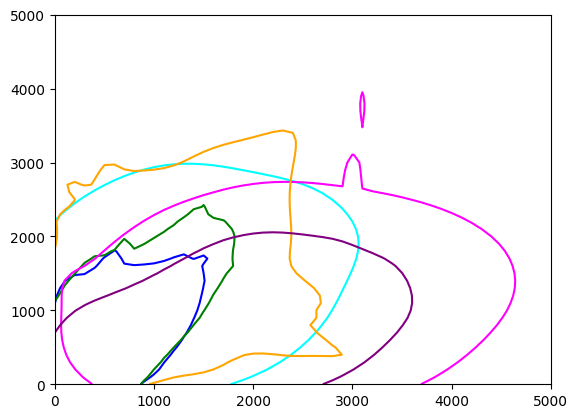

In [165]:
var = "jp"
col_lst = [grp_dict[sim][str(grp)] for grp in grp_lst[1:]]

xlim = (0, 5000)
ylim = (0, 5000)

for i, _ in enumerate(grp_lst[1:]):
    it_dict = group_dict_lst[i]
    col = col_lst[i]

    z_avg = get_z(it_dict, var, col, xlim, ylim, 100, 75)

plt.xlim(xlim)
plt.ylim(ylim)

In [163]:
grp_lst[1:], col_lst

([1920378, 4414957, 8580896, 13687078, 16199669, 19898495],
 ['blue', 'green', 'cyan', 'magenta', 'orange', 'purple'])

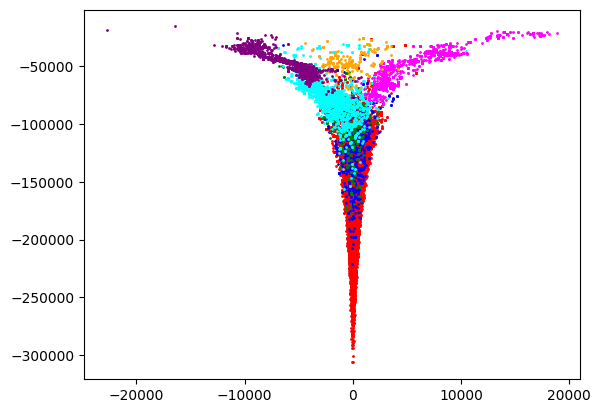

In [164]:
col_lst = [grp_dict[sim][str(grp)] for grp in grp_lst]

for i, group_id in enumerate(grp_lst):
    for it_id in proc_data.keys():
        snp_dat = proc_data[it_id]["snapshots"]["snap600"]
        grp_msk = snp_dat["group_id"][()] == group_id

        x = snp_dat["l.xyz"][:, 2][grp_msk]
        y = snp_dat["et"][grp_msk]

        plt.scatter(x, y, c=col_lst[i], s=1)

# plt.xlim(-1, 1)
# plt.ylim(-1, 0)